Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('C:\\Users\\saksh\\OneDrive\\Desktop\\AI-Cybersecurity-Project\\4_Python_Cleaning\\cleaned_data(python).csv')
df

,country,year,attack_type,target_industry,financial_loss_(in_million_$),number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_(in_hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,Vpn,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-In-The-Middle,It,38.65,605895,Hacker Group,Weak Passwords,Vpn,20
3,Uk,2024,Ransomware,Telecommunications,41.44,659320,Nation-State,Social Engineering,Ai-Based Detection,7
4,Germany,2018,Man-In-The-Middle,It,74.41,810682,Insider,Social Engineering,Vpn,68
...,...,...,...,...,...,...,...,...,...,...
2995,Uk,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,Sql Injection,Telecommunications,30.28,892843,Hacker Group,Zero-Day,Vpn,26
2997,Brazil,2017,Sql Injection,It,32.97,734737,Nation-State,Weak Passwords,Ai-Based Detection,30
2998,Uk,2022,Sql Injection,It,32.17,379954,Insider,Unpatched Software,Firewall,9


Attack type distribution

In [5]:
df['attack_type'].value_counts()

attack_type
Ddos                 531
Phishing             529
Sql Injection        503
Ransomware           493
Malware              485
Man-In-The-Middle    459
Name: count, dtype: int64

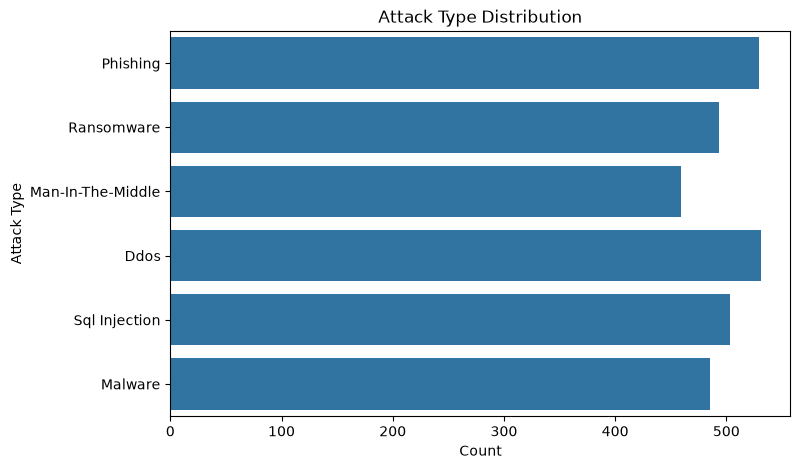

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='attack_type')
plt.title("Attack Type Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.show()

Attacks by year

In [9]:
yearly = df.groupby('year').size()

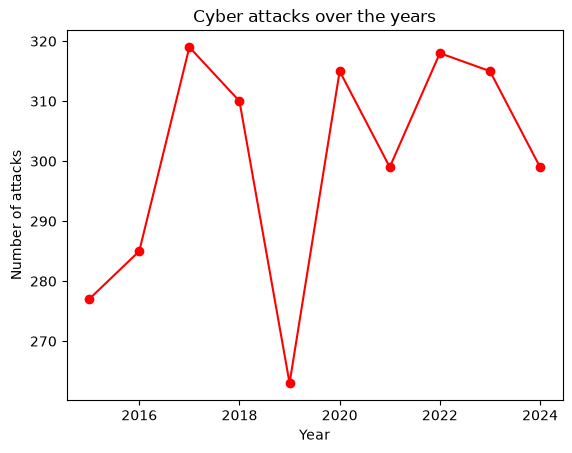

In [13]:
yearly.plot(kind='line', color='red', marker='o')
plt.title("Cyber attacks over the years")
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.show()

Top Countries Targeted

In [14]:
df['country'].value_counts().head(10)


country
Uk           321
Brazil       310
India        308
Japan        305
France       305
Australia    297
Russia       295
Germany      291
Usa          287
China        281
Name: count, dtype: int64

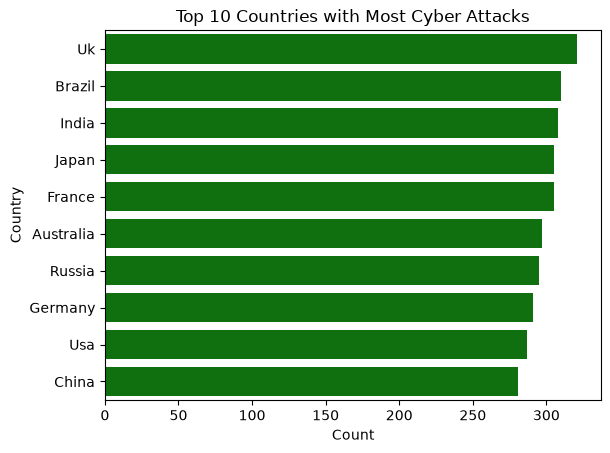

In [16]:
sns.countplot(data=df, y='country', color='green',
order= df['country'].value_counts().head(10).index)
plt.title("Top 10 Countries with Most Cyber Attacks")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

Industry Analysis

In [17]:
df

,country,year,attack_type,target_industry,financial_loss_(in_million_$),number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_(in_hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,Vpn,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-In-The-Middle,It,38.65,605895,Hacker Group,Weak Passwords,Vpn,20
3,Uk,2024,Ransomware,Telecommunications,41.44,659320,Nation-State,Social Engineering,Ai-Based Detection,7
4,Germany,2018,Man-In-The-Middle,It,74.41,810682,Insider,Social Engineering,Vpn,68
...,...,...,...,...,...,...,...,...,...,...
2995,Uk,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,Sql Injection,Telecommunications,30.28,892843,Hacker Group,Zero-Day,Vpn,26
2997,Brazil,2017,Sql Injection,It,32.97,734737,Nation-State,Weak Passwords,Ai-Based Detection,30
2998,Uk,2022,Sql Injection,It,32.17,379954,Insider,Unpatched Software,Firewall,9


In [18]:
df['target_industry'].value_counts()

target_industry
It                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Government            403
Telecommunications    403
Name: count, dtype: int64

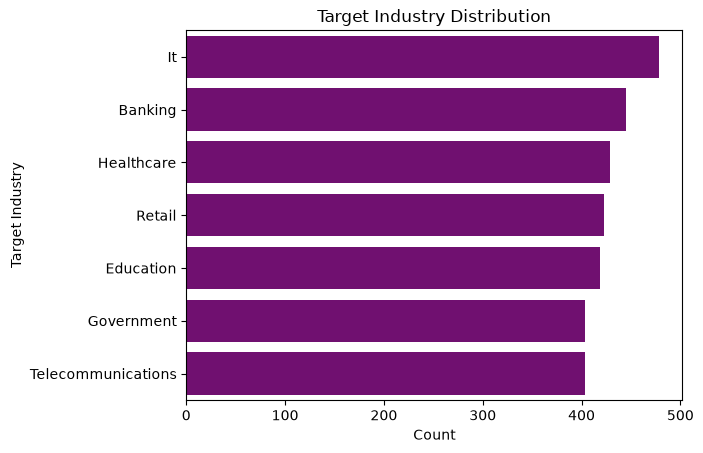

In [19]:
sns.countplot(data=df, y='target_industry', color='purple',
order=df['target_industry'].value_counts().index)
plt.title('Target Industry Distribution')
plt.xlabel('Count')
plt.ylabel('Target Industry')
plt.show()


Financial Impact Analysis

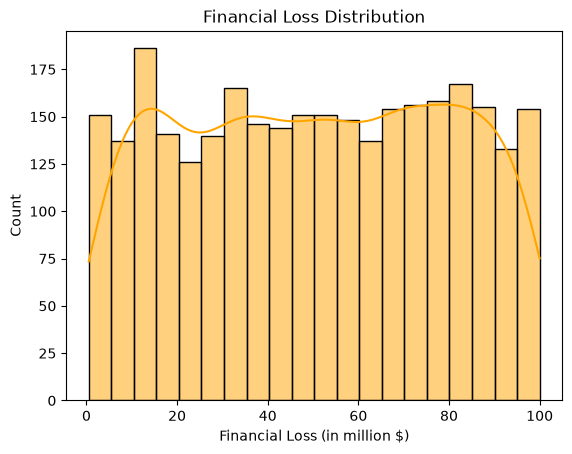

In [20]:
sns.histplot(df['financial_loss_(in_million_$)'],
bins = 20, color = 'orange', kde = True)
plt.title('Financial Loss Distribution')
plt.xlabel('Financial Loss (in million $)')
plt.ylabel('Count')
plt.show()

In [27]:
df.groupby('attack_type')['financial_loss_(in_million_$)'].mean()

attack_type
Ddos                 52.035631
Malware              49.418454
Man-In-The-Middle    51.309085
Phishing             50.459905
Ransomware           49.653793
Sql Injection        50.013042
Name: financial_loss_(in_million_$), dtype: float64

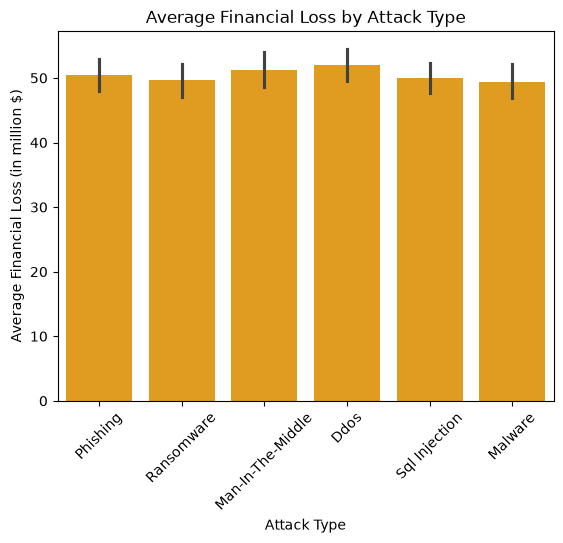

In [31]:
sns.barplot(x='attack_type', y='financial_loss_(in_million_$)', data=df, color='orange', estimator=np.mean)
plt.title('Average Financial Loss by Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Average Financial Loss (in million $)')
plt.xticks(rotation=45)
plt.show()

Number of Affected Users

In [33]:
df.groupby('attack_type')['number_of_affected_users'].mean()

attack_type
Ddos                 499437.410546
Malware              508780.232990
Man-In-The-Middle    520064.320261
Phishing             487179.536862
Ransomware           502825.369168
Sql Injection        512469.833002
Name: number_of_affected_users, dtype: float64

Top Incidents by affected users

In [34]:
df.nlargest(10, 'number_of_affected_users')

,country,year,attack_type,target_industry,financial_loss_(in_million_$),number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_(in_hours)
2045,Usa,2023,Ransomware,Government,93.34,999635,Nation-State,Weak Passwords,Firewall,24
323,France,2022,Sql Injection,Healthcare,27.06,999545,Hacker Group,Social Engineering,Encryption,47
2240,India,2020,Malware,It,84.43,999542,Hacker Group,Social Engineering,Encryption,15
2004,Usa,2016,Ransomware,Telecommunications,99.88,999508,Unknown,Unpatched Software,Vpn,23
2440,Usa,2020,Ddos,Banking,60.20,998937,Nation-State,Zero-Day,Antivirus,19
1515,India,2024,Ransomware,Government,79.30,998833,Hacker Group,Social Engineering,Firewall,21
2852,China,2021,Ransomware,Retail,40.01,998728,Unknown,Weak Passwords,Ai-Based Detection,68
2775,Uk,2023,Man-In-The-Middle,Banking,24.28,998547,Unknown,Weak Passwords,Antivirus,46
928,France,2019,Phishing,Retail,25.75,998507,Insider,Weak Passwords,Ai-Based Detection,15
1561,Usa,2016,Phishing,Retail,89.85,998085,Insider,Zero-Day,Vpn,7


Attack Source Analysis

In [59]:
attack_source_counts = df['attack_source'].value_counts()
attack_source_counts

attack_source
Nation-State    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

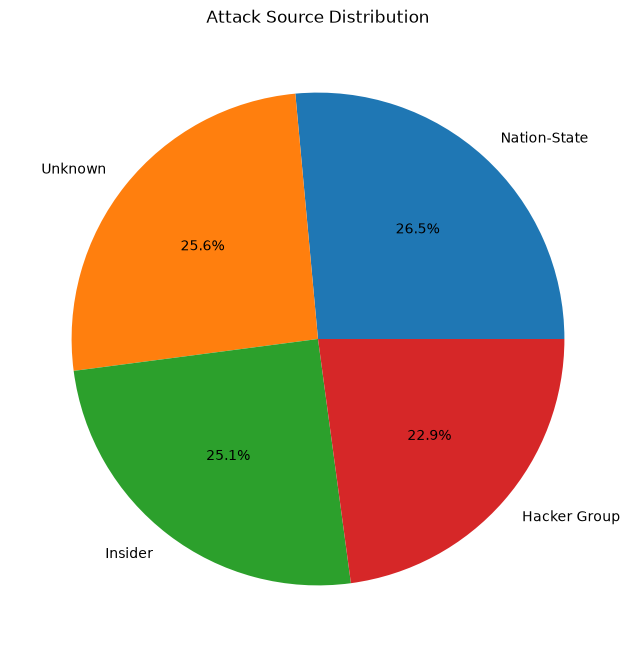

In [60]:
plt.figure(figsize=(8,8))
plt.pie(
    attack_source_counts,
    labels=attack_source_counts.index,
    autopct='%1.1f%%',
)
plt.title('Attack Source Distribution')
plt.show()

Security Vulnerability Analysis

In [39]:
df['security_vulnerability_type'].value_counts()

security_vulnerability_type
Zero-Day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64

Defence mechanism analysis

In [61]:
defense_counts =df['defense_mechanism_used'].value_counts()
defense_counts

defense_mechanism_used
Antivirus             628
Vpn                   612
Encryption            592
Firewall              585
Ai-Based Detection    583
Name: count, dtype: int64

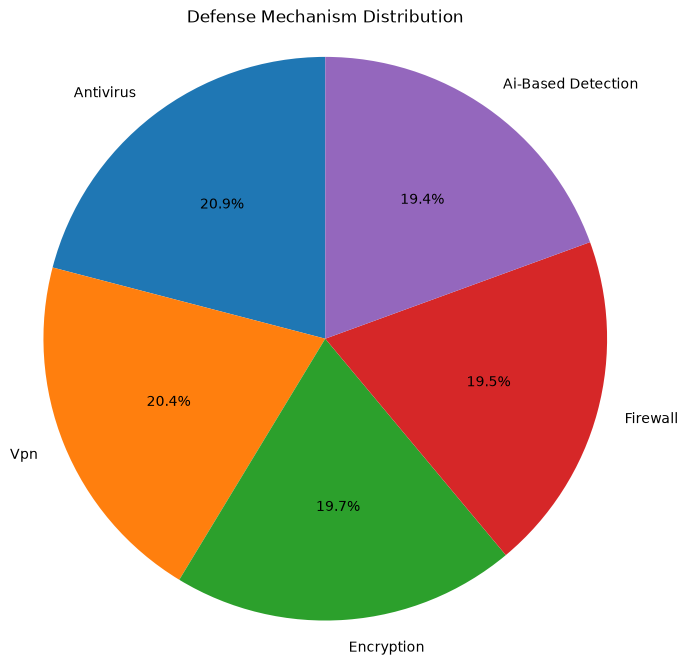

In [64]:
plt.figure(figsize=(8,8))
plt.pie(
    defense_counts,
    labels=defense_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Defense Mechanism Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


Defence Mechanism vs financial loss

In [41]:
df.groupby('defense_mechanism_used')['financial_loss_(in_million_$)'].mean()

defense_mechanism_used
Ai-Based Detection    50.361527
Antivirus             51.698838
Encryption            50.400203
Firewall              49.719709
Vpn                   50.209673
Name: financial_loss_(in_million_$), dtype: float64

Response time analysis

In [45]:
df['incident_resolution_time_(in_hours)'].mean()

np.float64(36.476)

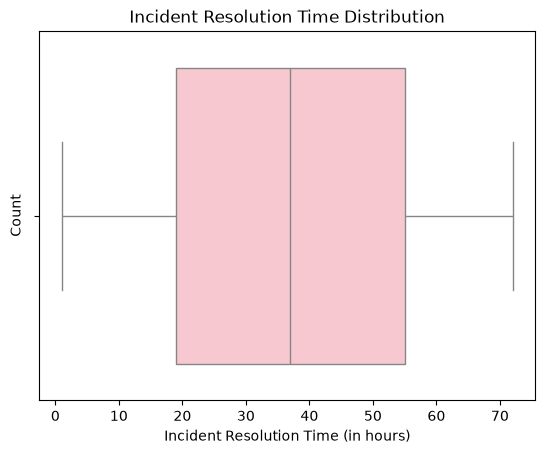

In [21]:
sns.boxplot(
    x=df['incident_resolution_time_(in_hours)'], color='pink'
)
plt.title('Incident Resolution Time Distribution')
plt.xlabel('Incident Resolution Time (in hours)')
plt.ylabel('Count')
plt.show()


Resolution time by attack type

In [46]:
df.groupby('attack_type')['incident_resolution_time_(in_hours)'].mean()

attack_type
Ddos                 35.687382
Malware              37.074227
Man-In-The-Middle    36.871460
Phishing             35.913043
Ransomware           36.533469
Sql Injection        36.906561
Name: incident_resolution_time_(in_hours), dtype: float64

Trend Analysis by year

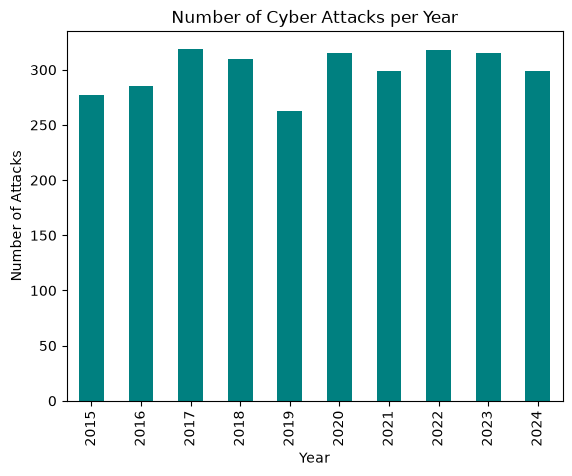

In [50]:
df.groupby('year').size().plot(kind='bar', color='teal')
plt.title('Number of Cyber Attacks per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()

Financial Loss trend

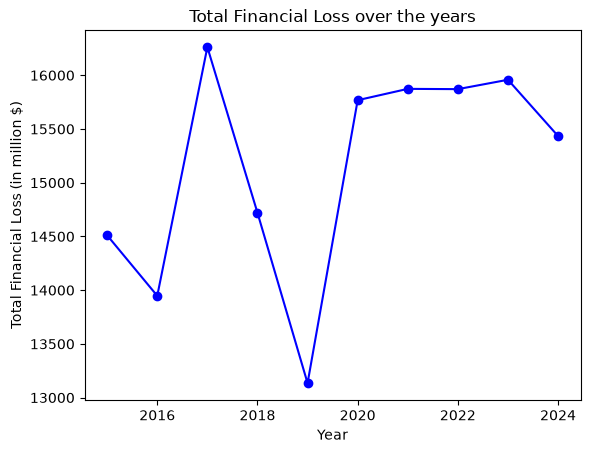

In [49]:
df.groupby('year')['financial_loss_(in_million_$)'].sum().plot(kind='line', color='blue', marker='o')
plt.title("Total Financial Loss over the years")
plt.xlabel("Year")
plt.ylabel("Total Financial Loss (in million $)")
plt.show()

Correlation Analysis

In [51]:
numeric_cols = [
    'financial_loss_(in_million_$)',
    'number_of_affected_users',
    'incident_resolution_time_(in_hours)'
]

In [ ]:
df[numeric_cols].corr()

,financial_loss_(in_million_$),number_of_affected_users,incident_resolution_time_(in_hours)
financial_loss_(in_million_$),1.000000,0.001787,-0.012671
number_of_affected_users,0.001787,1.000000,0.005893
incident_resolution_time_(in_hours),-0.012671,0.005893,1.000000


In [22]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [53]:
corr = numeric_df.corr()

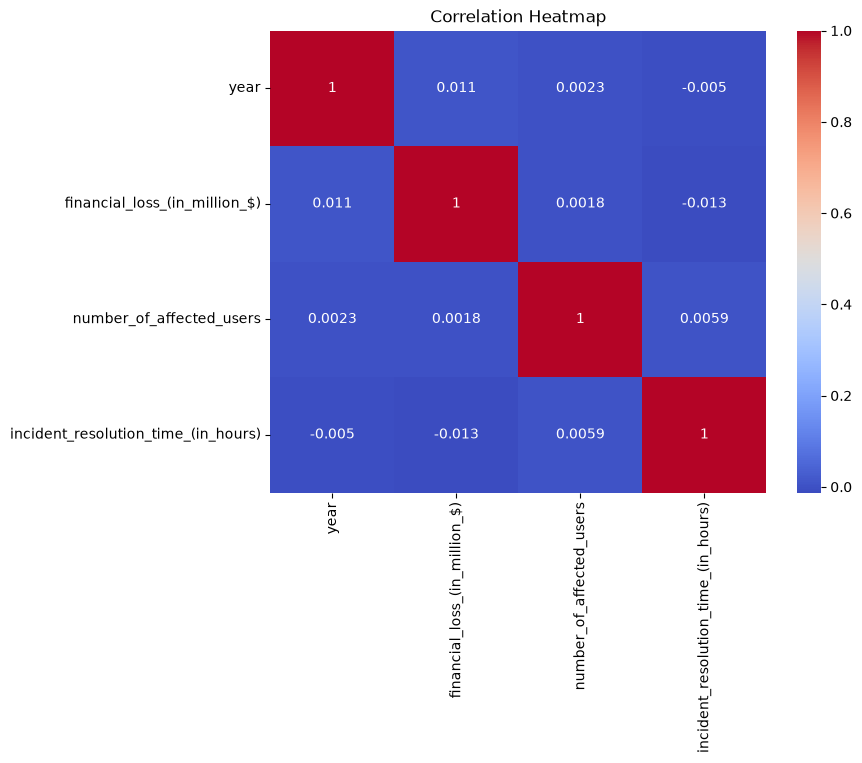

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()